## 손가락 숫자 모양의 Image 분류

#### Data Import

In [1]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
train_images = glob.glob('../Data/fingers/train/*.png')
test_images = glob.glob('../Data/fingers/test/*.png')

In [3]:
# file name 확인 -> glob.glob()
train_images[:5]

['../Data/fingers/train\\00048bba-979b-4f84-b833-5bbbb082b582_0L.png',
 '../Data/fingers/train\\000547a2-d456-4b16-b351-12ca9b40e390_0L.png',
 '../Data/fingers/train\\000cac8e-fcf0-4f8c-bd16-c257d1e6d7a8_2L.png',
 '../Data/fingers/train\\000d9961-8136-4dee-9820-86e178777958_0L.png',
 '../Data/fingers/train\\0010095b-2e3d-4517-a511-1f688c378f96_5L.png']

In [4]:
# 개수 확인
print(len(train_images))
print(len(test_images))

18000
3600


In [5]:
# train data 와 test data 만들기 : 128 * 128 -> 32 * 32
train_input = []
train_target = []
test_input = []
test_target = []

# train data
for image in sorted(train_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    train_input.append(imgResize)
    train_target.append(image[-6:-4]) # -> target 은 파일명 최후단 0L, 1L 등등으로 분류

# test data
for image in sorted(test_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    test_input.append(imgResize)
    test_target.append(image[-6:-4]) # -> target 은 파일명 최후단 0L, 1L 등등으로 분류

In [6]:
# Target Data 확인
print(train_target[:5])
print(test_target[:5])

['0L', '0L', '2L', '0L', '5L']
['5L', '5L', '3R', '5L', '5L']


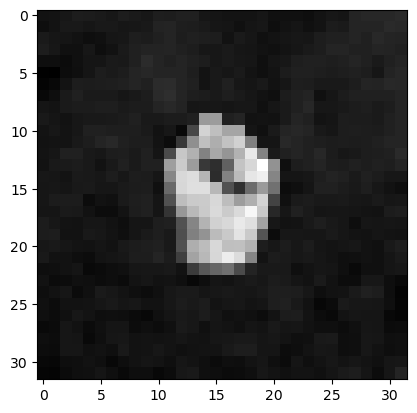

In [7]:
# train의 이미지 확인
plt.imshow(train_input[0], cmap='gray')
plt.show()

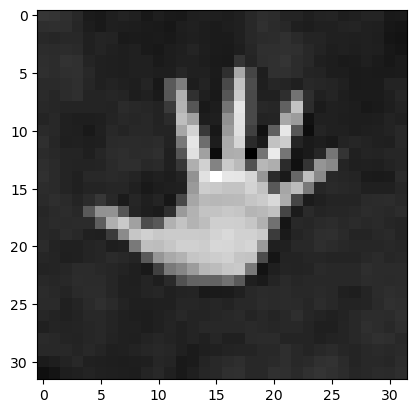

In [8]:
# train의 이미지 확인
plt.imshow(test_input[0], cmap='gray')
plt.show()

#### numpy 배열로 변경

In [9]:
import numpy as np

In [10]:
# train Data 만들기 (18000 * 32 * 32)
tempData = np.zeros(
    18000 * 32  * 32,
    dtype=np.int32
).reshape(18000, 32, 32)
tempData.shape

i = 0
for image in train_input:
    img = np.array(image, dtype=np.int32)
    tempData[i, :, :] = img
    i += 1

train_input = tempData.copy()

In [11]:
# test Data 만들기 (3600 * 32 * 32)
testData = np.zeros(
    3600 * 32  * 32,
    dtype=np.int32
).reshape(3600, 32, 32)
testData.shape

i = 0
for image in test_input:
    img = np.array(image, dtype=np.int32)
    testData[i, :, :] = img
    i += 1

test_input = testData.copy()

In [12]:
# 배열 크기 확인
print(train_input.shape, test_input.shape)

(18000, 32, 32) (3600, 32, 32)


---
#### Target을 숫자로 변경하기

In [13]:
label_to_int = {
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11,
}

In [14]:
# Train Target 숫자로 변경
temp = []
for label in train_target:
    temp.append(label_to_int[label])
train_target = temp.copy()

In [15]:
# Test Target 숫자로 변경
temp = []
for label in test_target:
    temp.append(label_to_int[label])
test_target = temp.copy()

In [16]:
print(type(train_target))

<class 'list'>


In [17]:
train_target[:5]

[6, 6, 8, 6, 11]

In [18]:
test_target[:5]

[11, 11, 3, 11, 11]

In [19]:
# Target 도 numpy배열로 변경
train_target = np.array(train_target)
test_target = np.array(test_target)

In [20]:
train_target

array([6, 6, 8, ..., 0, 8, 8], shape=(18000,))

In [21]:
test_target

array([11, 11,  3, ...,  4,  3,  3], shape=(3600,))

---
#### Deep Learning 구성하기

In [22]:
train_scaled = train_input / 255.0
test_scaled = test_input / 255.0

In [23]:
print("이미지 개수:", len(train_scaled)) # 예상: 18000
print("정답 라벨 개수:", len(train_target)) # 예상: 18000

이미지 개수: 18000
정답 라벨 개수: 18000


In [24]:
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split

# 1. 데이터 로드 및 전처리
# (train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

# 2D 이미지를 1D 데이터로 Flatten 및 정규화
# train_input_flatten = train_input.reshape(-1, 28*28)
# test_input_flatten = test_input.reshape(-1, 28*28)

train_scaled = train_input / 255.0
test_scaled = test_input / 255.0

# Train / Validation 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

# 2. 모델 생성
model = keras.Sequential()
# 맨 앞에 Flatten 층을 추가하여 (32, 32) 이미지를 1024로 자동 변환합니다.
model.add(keras.layers.Flatten(input_shape=(32, 32), name='flatten'))
# 
model.add(keras.layers.Dense(100, activation='relu', name='hidden1')) # input_shape = 모델에 들어오는 데이터 1개의 형태 = 이미지 크기 (32 * 32)
model.add(keras.layers.Dense(50, activation='relu', name='hidden2'))
model.add(keras.layers.Dense(12, activation='softmax', name='output')) # 출력층 개수 = 내가 분류하고 싶은 정답(클래스)의 총 개수

# 3. 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. 최적 모델 저장을 위한 콜백 설정
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath='best-model.keras', 
    monitor='val_accuracy',       # 검증 정확도 기준
    save_best_only=True           # 최고 성능 모델만 저장
)

# 5. 모델 훈련
history = model.fit(
    train_scaled,
    train_target,
    epochs=40,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb],
    verbose=1
)

# 6. 최적의 에포크 인덱스 찾기
val_accuracy_list = history.history['val_accuracy'] # -> model.fit() 함수 실행 결과가 자동으로 history 딕셔너리 변수에 저장됨. 해당 변수에 loss, accuracy, val_loss, val_accuracy 등이 저장됨.
best_epoch_index = np.argmax(val_accuracy_list) # 리스트 인덱스 (0부터 시작)
best_epoch = best_epoch_index + 1               # 실제 에포크 차수 (1부터 시작)

# 7. 최적 에포크 시점의 Train 및 Valid 정확도 추출
best_train_accuracy = history.history['accuracy'][best_epoch_index]
best_val_accuracy = val_accuracy_list[best_epoch_index]

# 8. 가장 성능이 좋았던 저장된 모델을 불러와 Test 정확도 측정
best_model = keras.models.load_model('best-model.keras')
test_loss, best_test_accuracy = best_model.evaluate(test_scaled, test_target, verbose=0)

# 9. 최종 결과 출력
print("\n" + "="*50)
print(f"🥇 최적의 에포크: {best_epoch} epoch")
print("-"*50)
print(f"📈 [Train]       훈련 정확도: {best_train_accuracy * 100:.2f}%")
print(f"🧪 [Validation]  검증 정확도: {best_val_accuracy * 100:.2f}%")
print(f"🎯 [Test]        🎯 최종 테스트 정확도: {best_test_accuracy * 100:.2f}%")
print("="*50)

Epoch 1/40


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8190 - loss: 0.7424 - val_accuracy: 0.9583 - val_loss: 0.2111
Epoch 2/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9704 - loss: 0.1308 - val_accuracy: 0.9631 - val_loss: 0.1308
Epoch 3/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9869 - loss: 0.0581 - val_accuracy: 0.9922 - val_loss: 0.0388
Epoch 4/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9944 - loss: 0.0295 - val_accuracy: 0.9961 - val_loss: 0.0224
Epoch 5/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9936 - loss: 0.0272 - val_accuracy: 0.9961 - val_loss: 0.0180
Epoch 6/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9978 - loss: 0.0122 - val_accuracy: 0.9833 - val_loss: 0.0475
Epoch 7/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9978 - loss: 0.0125 - val_accuracy: 0.9939 - val_loss: 0.0304
Epoch 8/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9960 - loss: 0.0137 - val_accuracy: 0.9986 - val_

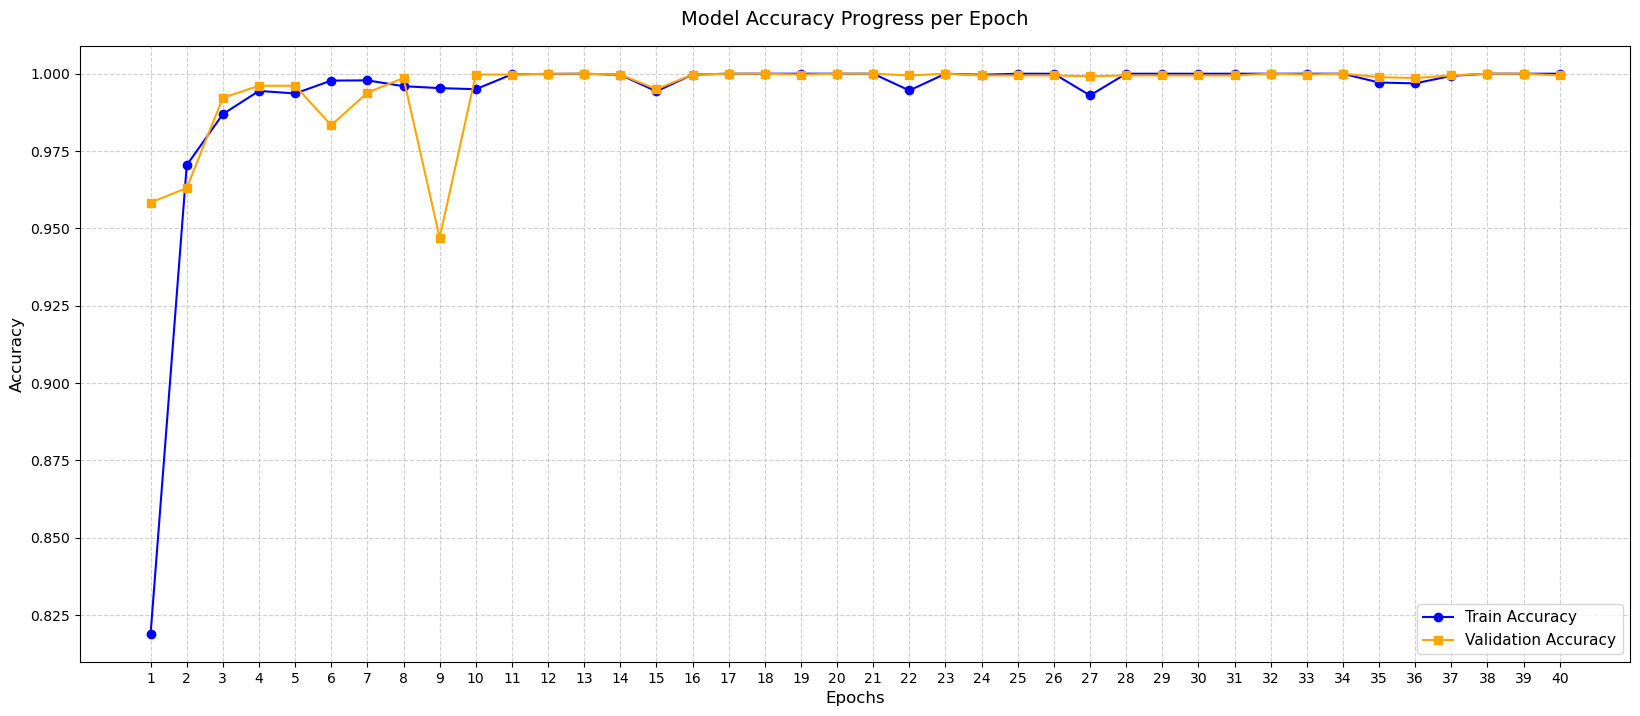

In [25]:
import matplotlib.pyplot as plt

# 1. history 객체에서 에포크별 train, valid 정확도 리스트 추출
train_acc_list = history.history['accuracy']
valid_acc_list = history.history['val_accuracy']

# 2. 에포크 수를 기준으로 x축 설정 (1부터 시작)
epochs_range = range(1, len(train_acc_list) + 1)

# 3. 그래프 그리기
plt.figure(figsize=(20, 8)) # 그래프 크기 설정
plt.plot(epochs_range, train_acc_list, label='Train Accuracy', marker='o', color='blue')
plt.plot(epochs_range, valid_acc_list, label='Validation Accuracy', marker='s', color='orange')

# 4. 그래프 꾸미기 (제목, 축 레이블, 범례 등)
plt.title('Model Accuracy Progress per Epoch', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs_range) # x축 눈금을 에포크 정수로 고정
plt.grid(True, linestyle='--', alpha=0.6) # 배경 격자 추가
plt.legend(loc='lower right', fontsize=11) # 범례 위치 설정

# 5. 화면에 그래프 출력
plt.show()

1. Aama 옵티마이저는 빠른 학습 속도 대신 특이한 배치 데이터를 만나면 가중치가 부정적적인 방향으로 크게 튈 수 있음. 그러나, 이후 학습을 통해 원상 복구됨 (= Epoch 9 구간)</br>
2. 평가 시점의 차이 : 학습 정확도(Train Accuracy)는 해당 Epoch에서 실시간으로 계산된 평균치인 반면, 검증 정확도(Validation Accuracy)는 해당 Epoch의 모든 학습이 끝난 완전체 상태로 단 한 번 측정한 값. 따라서, validation > train 현상이 발생할 수 있다 -> 이는, 과적합 발생 징후가 없다는 의미이며 학습 과정에서 긍정적인 형태 (= Epoch 8, 10, 22, 27 구간)</br>
3. Train Accuracy 와 Validation Accuracy 수치 모두 100%(1.0) = 구분하고자 했던 12개의 클래스를 완벽하게 구분할 수 있는 규칙을 모델이 찾아냈다는 의미.</br>
(긍정) : 정답률 100% 완벽한 모델 (부정) : 과적합 위험성